In [ ]:
                  #Muhammad Daniyal
                  #DHC-9027

# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [45]:
# STEP 2: LOAD DATASET

import pandas as pd

# Load the CSV file into a pandas DataFrame.
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

In [46]:
# STEP 3: DISPLAY BASIC DATASET INFORMATION

# Display first 5 rows (df was loaded in STEP 2)
print("\nFirst 5 Rows of Dataset:")
print(df.head())


First 5 Rows of Dataset:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [47]:
# STEP 4: DATASET INFORMATION


print("\nDataset Information:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe)


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

Missing Values:

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Statistical Summary:

<bound method NDFrame.describe of         Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5

In [48]:
# STEP 5: IDENTIFY TARGET COLUMN


target_column = 'Price'

# Features (X)
X = df.drop(target_column, axis=1)

# Target Variable (y)
y = df[target_column]

In [49]:
# STEP 6: SEPARATE NUMERICAL & CATEGORICAL FEATURES


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='object')

Categorical Features:
Index(['Location', 'Condition', 'Garage'], dtype='object')


In [50]:
# STEP 7: CREATE PREPROCESSING PIPELINES


# Numerical Data Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Data Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [51]:
# STEP 8: SPLIT DATASET INTO TRAINING & TESTING


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (1600, 9)
Testing Data Shape: (400, 9)


In [61]:
# STEP 9: TRAIN LINEAR REGRESSION MODEL


linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train Model
linear_model.fit(X_train, y_train)

# Make Predictions
linear_predictions = linear_model.predict(X_test)


In [62]:
# STEP 10: EVALUATE LINEAR REGRESSION MODEL


linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")

print("MAE  :", linear_mae)
print("RMSE :", linear_rmse)
print("R2 Score :", linear_r2)




LINEAR REGRESSION RESULTS
MAE  : 242867.44926338628
RMSE : 279785.21069002635
R2 Score : -0.006181784611834162


In [54]:
# STEP 11: TRAIN GRADIENT BOOSTING MODEL


gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# Train Model
gb_model.fit(X_train, y_train)

# Make Predictions
gb_predictions = gb_model.predict(X_test)

In [55]:
# STEP 12: EVALUATE GRADIENT BOOSTING MODEL


gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_predictions)
)

gb_r2 = r2_score(y_test, gb_predictions)

print("\n==============================")
print("GRADIENT BOOSTING RESULTS")
print("==============================")

print("MAE  :", gb_mae)
print("RMSE :", gb_rmse)
print("R2 Score :", gb_r2)


GRADIENT BOOSTING RESULTS
MAE  : 246298.1273507895
RMSE : 284876.3509577617
R2 Score : -0.04313312782405343


In [56]:
# STEP 13: MODEL COMPARISON TABLE


comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'MAE': [linear_mae, gb_mae],
    'RMSE': [linear_rmse, gb_rmse],
    'R2 Score': [linear_r2, gb_r2]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)




MODEL COMPARISON
               Model            MAE           RMSE  R2 Score
0  Linear Regression  242867.449263  279785.210690 -0.006182
1  Gradient Boosting  246298.127351  284876.350958 -0.043133


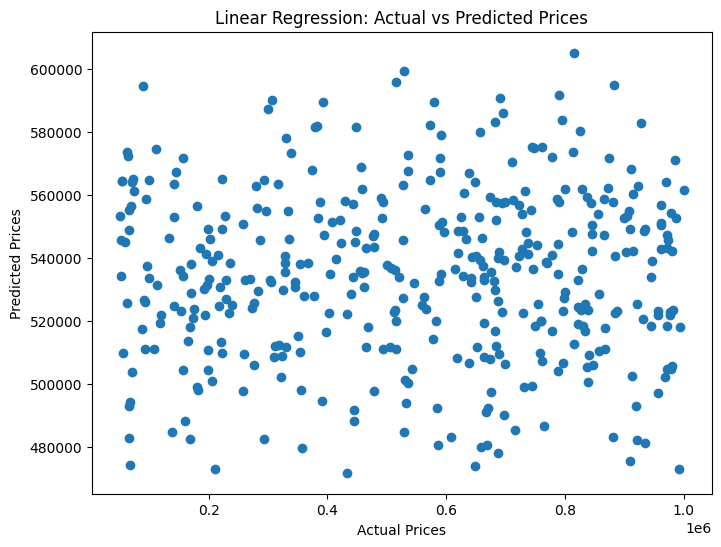

In [57]:
# STEP 14: VISUALIZATION
# ACTUAL VS PREDICTED (LINEAR REGRESSION)


plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Linear Regression: Actual vs Predicted Prices")

plt.show()


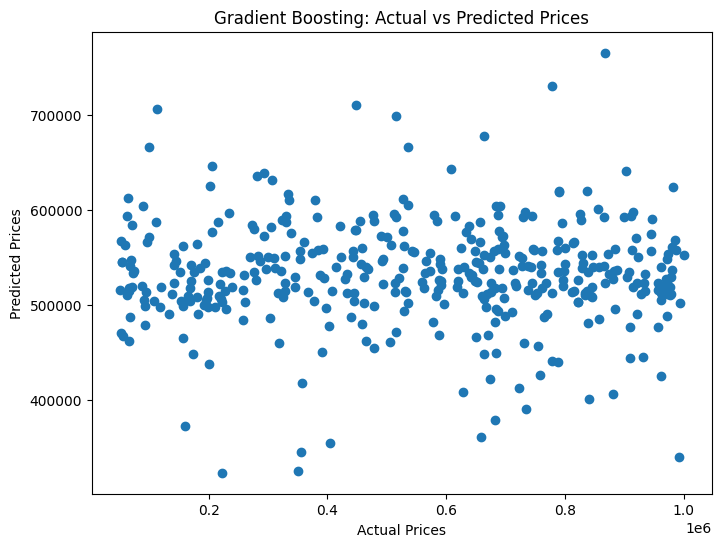

In [58]:

# STEP 15: VISUALIZATION
# ACTUAL VS PREDICTED (GRADIENT BOOSTING)


plt.figure(figsize=(8,6))

plt.scatter(y_test, gb_predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Gradient Boosting: Actual vs Predicted Prices")

plt.show()

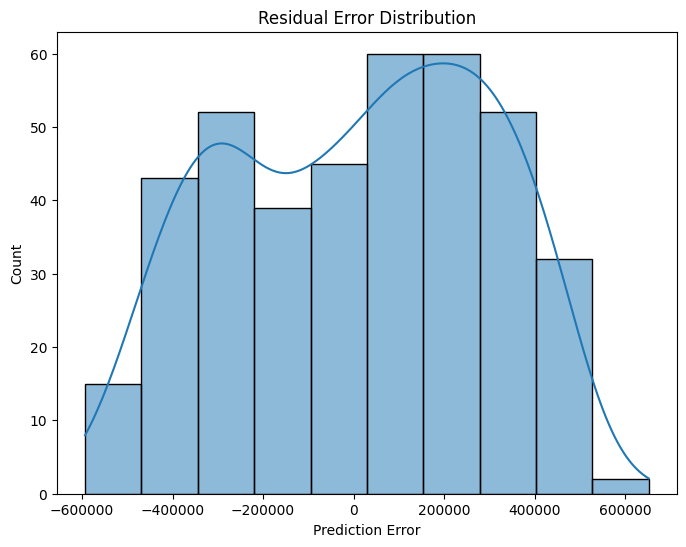

In [59]:
# STEP 16: RESIDUAL ERROR DISTRIBUTION


# Residuals = Actual - Predicted
residuals = y_test - gb_predictions

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [60]:
# STEP 17: SAMPLE PREDICTIONS


results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': gb_predictions
})

print("\nSample Predictions:\n")

print(results.head(10))


Sample Predictions:

   Actual Price  Predicted Price
0        514764    699148.456847
1        694256    517730.482189
2         66375    514569.399560
3        650243    545625.439902
4        223285    535088.206902
5        468127    538437.139063
6        513002    513631.718161
7        911525    593573.942415
8        723265    551412.148776
9        339416    576416.764774
